In [15]:
# imports and connection
import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from snowflake_config import SNOWFLAKE_CONFIG

# connect to snowflake
conn = snowflake.connector.connect(**SNOWFLAKE_CONFIG)
cursor = conn.cursor()

print("Connected successfully!")

Connected successfully!


In [16]:
# reusable query function
def run_query(sql):
    cursor.execute(sql)
    df = cursor.fetch_pandas_all()
    return df

In [17]:
# sanity check
df = run_query("""
    select 
        count(*) as total_sessions,
        count(distinct user_id) as total_users,
        sum(session_revenue) as total_revenue
    from fct_sessions
""")

df

,TOTAL_SESSIONS,TOTAL_USERS,TOTAL_REVENUE
0,89700700,15639776,2.057446e+09


In [18]:
# Funnel Analysis

'''This notebook analyzes the drop-off rate between each stage 
of the user journey — from first view through adding to cart 
to completing a purchase.

**Key question: where are we losing the most users?**

Data source: Snowflake `fct_sessions` mart
Dataset period: December 2019 — April 2020'''

'This notebook analyzes the drop-off rate between each stage \nof the user journey — from first view through adding to cart \nto completing a purchase.\n\n**Key question: where are we losing the most users?**\n\nData source: Snowflake `fct_sessions` mart\nDataset period: December 2019 — April 2020'

In [19]:
funnel_df = run_query("""
    select
        session_stage,
        count(*) as sessions,
        round(count(*) * 100.0 / sum(count(*)) over (), 2) as pct_of_total
    from fct_sessions
    group by 1
    order by sessions desc
""")

funnel_df

,SESSION_STAGE,SESSIONS,PCT_OF_TOTAL
0,viewed,78455316,87.46
1,carted,5795450,6.46
2,purchased,5449934,6.08


In [20]:
## Funnel Drop-off

'''Now let's visualize where users are dropping off.'''

"Now let's visualize where users are dropping off."

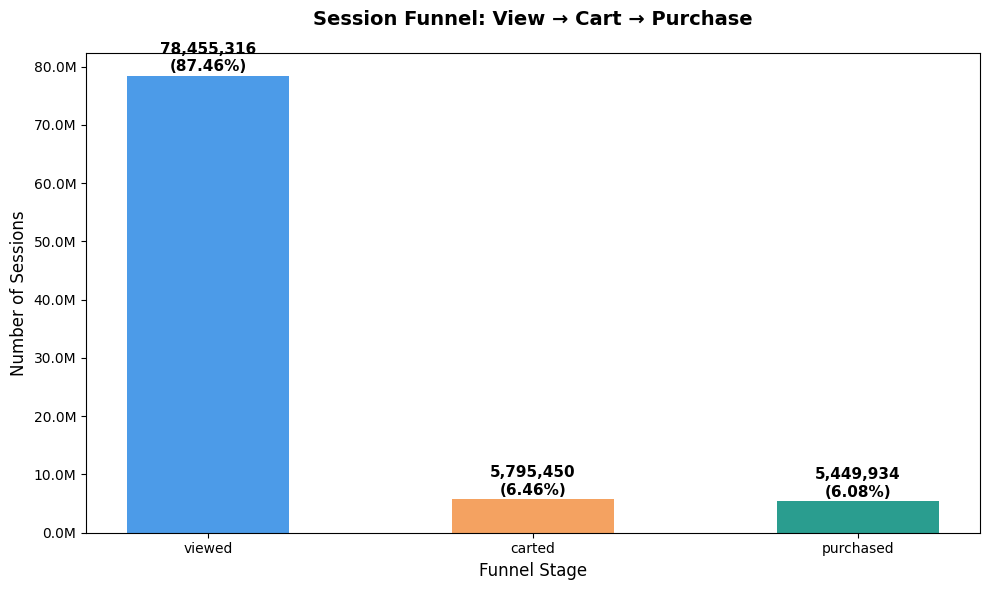

In [21]:
# define correct funnel order
stage_order = ['viewed', 'carted', 'purchased']

# filter and sort
plot_df = funnel_df[
    funnel_df['SESSION_STAGE'].isin(stage_order)
].copy()

plot_df['SESSION_STAGE'] = pd.Categorical(
    plot_df['SESSION_STAGE'], 
    categories=stage_order, 
    ordered=True
)
plot_df = plot_df.sort_values('SESSION_STAGE')

# plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    plot_df['SESSION_STAGE'],
    plot_df['SESSIONS'],
    color=['#4C9BE8', '#F4A261', '#2A9D8F'],
    width=0.5
)

# add value labels on bars
for bar, (_, row) in zip(bars, plot_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200000,
        f"{row['SESSIONS']:,.0f}\n({row['PCT_OF_TOTAL']}%)",
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Session Funnel: View → Cart → Purchase', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Funnel Stage', fontsize=12)
ax.set_ylabel('Number of Sessions', fontsize=12)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

plt.tight_layout()
plt.show()

In [8]:
# Cell 8 - step by step conversion rates
conv_df = run_query("""
    with stages as (
        select
            sum(case when session_stage = 'viewed'    then 1 else 0 end) as viewed,
            sum(case when session_stage = 'carted'    then 1 else 0 end) as carted,
            sum(case when session_stage = 'purchased' then 1 else 0 end) as purchased
        from fct_sessions
    )

    select
        viewed,
        carted,
        purchased,
        round(carted * 100.0 / viewed, 2)    as view_to_cart_pct,
        round(purchased * 100.0 / carted, 2) as cart_to_purchase_pct,
        round(purchased * 100.0 / viewed, 2) as overall_conversion_pct
    from stages
""")

conv_df

,VIEWED,CARTED,PURCHASED,VIEW_TO_CART_PCT,CART_TO_PURCHASE_PCT,OVERALL_CONVERSION_PCT
0,78455316,5795450,5449934,7.39,94.04,6.95


In [22]:
# user level funnel
user_funnel_df = run_query("""
    select
        user_type,
        count(distinct user_id) as users,
        round(count(distinct user_id) * 100.0 / 
            sum(count(distinct user_id)) over (), 2) as pct_of_total
    from dim_users
    group by 1
    order by users desc
""")

user_funnel_df

,USER_TYPE,USERS,PCT_OF_TOTAL
0,browser,13574878,86.80
1,repeat buyer,1082280,6.92
2,one-time buyer,982618,6.28


In [10]:
'''Among converted users, repeat buyers slightly outnumber one-time buyers — suggesting strong product-market fit 
and good retention among paying customers. 
The real challenge is converting the 87% of browsers.'''

'Among converted users, repeat buyers slightly outnumber one-time buyers — suggesting strong product-market fit \nand good retention among paying customers. \nThe real challenge is converting the 87% of browsers.'

In [23]:
true_funnel_df = run_query("""
    with user_actions as (
        select
            user_id,
            max(has_view)     as ever_viewed,
            max(has_cart)     as ever_carted,
            max(has_purchase) as ever_purchased
        from fct_sessions
        group by 1
    )

    select
        sum(ever_viewed)                                        as viewed_users,
        sum(ever_carted)                                        as carted_users,
        sum(ever_purchased)                                     as purchased_users,
        round(sum(ever_carted) * 100.0 /
            sum(ever_viewed), 2)                                as view_to_cart_pct,
        round(sum(ever_purchased) * 100.0 /
            sum(ever_carted), 2)                                as cart_to_purchase_pct,
        round(sum(ever_purchased) * 100.0 /
            sum(ever_viewed), 2)                                as overall_conversion_pct
    from user_actions
""")

true_funnel_df

,VIEWED_USERS,CARTED_USERS,PURCHASED_USERS,VIEW_TO_CART_PCT,CART_TO_PURCHASE_PCT,OVERALL_CONVERSION_PCT
0,15634925,3584761,2064898,22.93,57.60,13.21


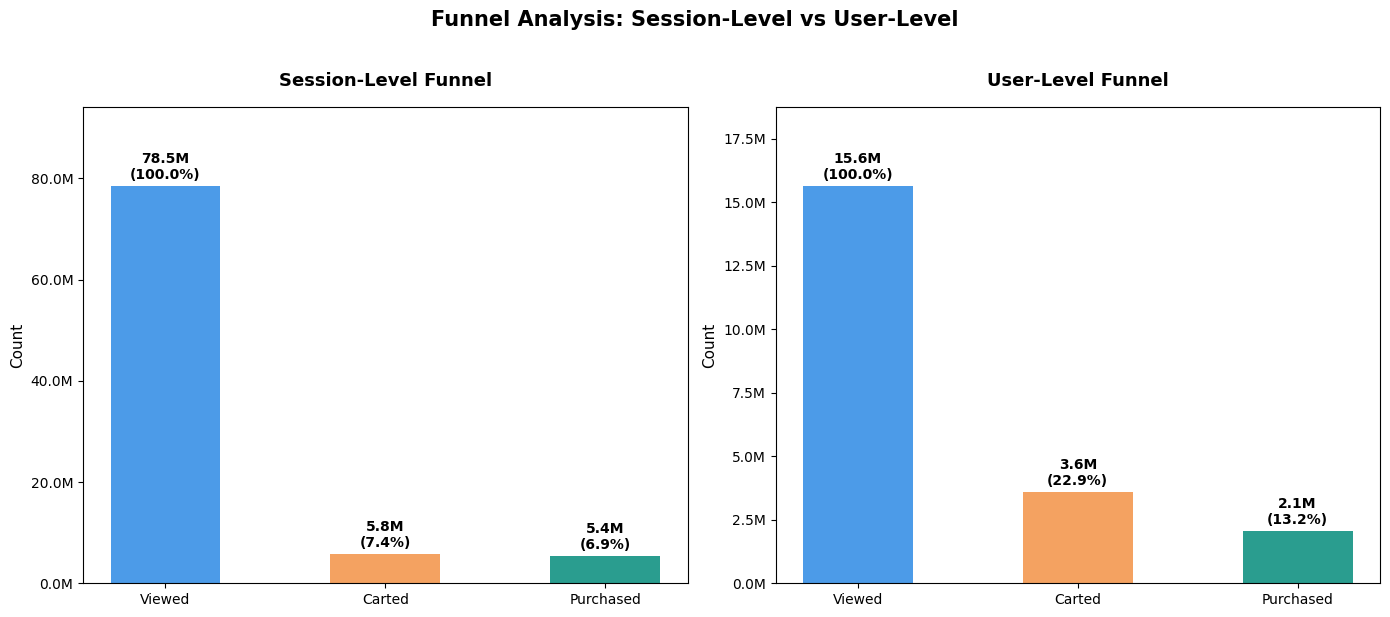

In [24]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

stages = ['Viewed', 'Carted', 'Purchased']

# session level values
session_values = [
    conv_df['VIEWED'].values[0],
    conv_df['CARTED'].values[0],
    conv_df['PURCHASED'].values[0]
]

# user level values
user_values = [
    true_funnel_df['VIEWED_USERS'].values[0],
    true_funnel_df['CARTED_USERS'].values[0],
    true_funnel_df['PURCHASED_USERS'].values[0]
]

colors = ['#4C9BE8', '#F4A261', '#2A9D8F']

for ax, values, title in zip(
    axes,
    [session_values, user_values],
    ['Session-Level Funnel', 'User-Level Funnel']
):
    bars = ax.bar(stages, values, color=colors, width=0.5)
    
    for bar, val in zip(bars, values):
        pct = val / values[0] * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.01,
            f'{val/1e6:.1f}M\n({pct:.1f}%)',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold'
        )
    
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax.set_ylabel('Count', fontsize=11)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
    )
    ax.set_ylim(0, max(values) * 1.2)

plt.suptitle(
    'Funnel Analysis: Session-Level vs User-Level',
    fontsize=15, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.show()

In [13]:
## Comments

'''I built two funnel perspectives intentionally. The session-level funnel shows engagement patterns within visits — useful for UX decisions 
like where users lose interest. The user-level funnel shows true conversion across the entire journey — useful for understanding how many 
users actually move through each stage. They tell different stories and answer different business questions.

Session-level funnel significantly underestimates cart abandonment because users frequently browse in one session and purchase in another. 
User-level analysis reveals a 43% cart abandonment rate — meaning nearly half of interested users never complete their purchase. 
This is the primary conversion opportunity.'''

'I built two funnel perspectives intentionally. The session-level funnel shows engagement patterns within visits — useful for UX decisions \nlike where users lose interest. The user-level funnel shows true conversion across the entire journey — useful for understanding how many \nusers actually move through each stage. They tell different stories and answer different business questions.\n\nSession-level funnel significantly underestimates cart abandonment because users frequently browse in one session and purchase in another. \nUser-level analysis reveals a 43% cart abandonment rate — meaning nearly half of interested users never complete their purchase. \nThis is the primary conversion opportunity.'